Imports

In [17]:
import xobjects as xo
import xtrack as xt
import xpart as xp

import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 

clight=constants.speed_of_light

In [18]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from tqdm import tqdm
from ipywidgets import interact, IntSlider
from matplotlib.animation import FuncAnimation, PillowWriter

from matplotlib.ticker import ScalarFormatter
from scipy.optimize import curve_fit
import os

# Generalized variables
textwidth_cm = 16.50764  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 12
legend_fontsize = 12
tick_fontsize = 10
colorbar_label_fontsize = 12
colorbar_tick_fontsize = 10
offset_text_fontsize = 12
tick_fontsize = 10
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

save_dir = '/home/pkruyt/cernbox/figures_thesis/'

In [19]:
from ion_properties import lead,xenon,calcium

ion=lead
q0=ion.q0
mass0 = ion.mass0

gamma = ion.gamma_rel
beta = ion.beta_rel # ion beta
p0c = gamma*mass0*beta #eV/c
# p0c*1e-12/





Ion properties

In [20]:

# plt.figure(figsize=(12, 8))
# plt.rcParams.update({'font.size': 25})

# for ion in [lead]:# Ion properties:
#         # Ion properties:
#         q0=ion.q0
#         mass0 = ion.mass0

#         gamma = ion.gamma_rel
#         beta = ion.beta_rel # ion beta
#         p0c = gamma*mass0*beta #eV/c

#         # Source: https://www.sciencedirect.com/science/article/pii/S0146641020300399
#         # Equation 4.4
#         N_pb = int(1.9*1e8) #ion-bunch intensity for lead
#         N_a = int(N_pb*(ion.Z/82)**-1.9) #ion-bunch intensity for arbitrary ion with charge Z

#         # Source: https://www.sciencedirect.com/science/article/pii/S0146641020300399
#         # Ion beam dimensions:
#         sigma_x = 1.047e-3 # m
#         sigma_y = 0.83e-3  # m
#         sigma_z = 0.063 # m
#         sigma_dp = 2e-4 # relative ion momentum spread

#         sigma_px=4.36*1e-3 #calculated from the Twiss parameters
#         sigma_py=4.36*1e-3 #calculated from the Twiss parameters

#         num_particles = int(1e3)

#         particles0 = xp.Particles(
#         mass0 = mass0, # eV/c^2
#         q0    = q0,
#         p0c   = p0c, # eV
#         x     = np.random.normal(scale=sigma_x, size=num_particles),
#         px    = np.random.normal(scale=sigma_px, size=num_particles),
#         y     = np.random.normal(scale=sigma_y, size=num_particles),
#         py    = np.random.normal(scale=sigma_py, size=num_particles),
#         zeta  = np.random.normal(scale=sigma_z, size=num_particles),
#         delta = np.random.normal(scale=sigma_dp, size=num_particles)
#                 )

#         ##################
#         # Laser Cooler #
#         ##################

#         #Laser-ion beam collision angle
#         theta_l = 2.6*np.pi/180 # rad
#         nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

#         ion_excited_lifetime=ion.excited_lifetime
#         # Ion excitation energy:
#         hw0 = ion.hw0
#         hc=constants.hbar*clight/constants.e # eV*m (ħc)
#         lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

#         lambda_l = lambda_0*gamma*(1 + beta*np.cos(theta_l)) # m -- laser wavelength

        
#         # Shift laser wavelength for fast longitudinal cooling:
#         # lambda_l = lambda_l*(1+sigma_dp) # m

#         laser_frequency = clight/lambda_l # Hz
#         sigma_w = 2*np.pi*laser_frequency*sigma_dp
#         #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

#         sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
#         #print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
        
#         #print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

#         laser_waist_radius = 1.3e-3 #m
#         laser_energy = 5e-3

#         GF_IP = xt.PulsedLaser(
#                         laser_x=0,
#                         laser_y=0,
#                         laser_z=0,
                        
#                         laser_direction_nx = 0,
#                         laser_direction_ny = ny,
#                         laser_direction_nz = nz,
#                         laser_energy         = laser_energy, # J
#                         laser_duration_sigma = sigma_t, # sec
#                         laser_wavelength = lambda_l, # m
#                         laser_waist_radius = laser_waist_radius, # m
#                         laser_waist_shift = 0, # m
#                         ion_excitation_energy = hw0, # eV
#                         ion_excited_lifetime  = ion_excited_lifetime, # sec                   
#                         )

#         particles=particles0.copy()

#         GF_IP.track(particles)

#         excited=particles.state==2

#         fraction_excitation = sum(excited)/len(excited)

        

#         print(f'Intensity of ion beam               : {N_a:.2e}')
#         print(f'Fraction of excited particles       : {fraction_excitation*100:.3}%')
#         print(f'Number of emitted photons per bunch : {fraction_excitation*N_a:.2e}')
#         print('-----------------------------------------------------------------------')
        
#         omega_laser = 2 * np.pi * hc / lambda_l

#         maximum_emitted_photon=hw0*2*gamma #Lorentz boost

#         print(f'Laser_photon: {omega_laser:.2f} ev')
#         print(f'hw0: {hw0:.2f} ev')
#         print(f'Maximum_emitted_photon: {maximum_emitted_photon*1e-3:.2f} Kev')

#         # Random polar angle in the ion's frame:
#         costheta = np.random.uniform(-1,+1, size=num_particles)
#         theta_emitt_ion = np.arccos(costheta)

#         # Emitted photon energy in the lab frame:
#         hw1_emitted = gamma*(1+particles0.delta) * ( 1 + beta*np.cos(theta_emitt_ion) )*hw0 # eV
#         # Only excited atoms are emitting of course:
#         hw1_excited_and_emitted = hw1_emitted *excited

#         # Transverse emission doesn't have lorentz boost.
#         # Only longitudinal has Lorenzt boost.
#         # Therefore, the angle of outgoing angle of the photons is the Lorentz boost theta_emitt/(2*gamma)

#         theta_photon_lab=theta_emitt_ion/(2*gamma) 

#         plt.scatter(theta_photon_lab*1e3,hw1_emitted*1e-3,label=f'{ion.name}') #can also plot hw1_excited_and_emitted instead of hw1_emitted
# plt.xlabel('$\Theta$ [mrad]')
# plt.ylabel('Energy [keV]')
# #plt.legend()
# plt.tight_layout()
# plt.savefig('figures/Photon_energy_distribution.png', dpi=300)
# plt.show()

attempt 2 taking into account the momentum of the ions

<>:140: SyntaxWarning: invalid escape sequence '\T'
<>:140: SyntaxWarning: invalid escape sequence '\T'
/tmp/pkruyt/ipykernel_98771/1328569208.py:140: SyntaxWarning: invalid escape sequence '\T'
  plt.xlabel('$\Theta$ [mrad]')


Intensity of ion beam               : 9.00e+07
Fraction of excited particles       : 14.0%
Number of emitted photons per bunch : 1.26e+07
-----------------------------------------------------------------------
Number of emitted photons per bunch per second : 5.46e+11
Number of emitted photons per second : 1.96e+13
-----------------------------------------------------------------------
Laser_photon: 1.20 ev
hw0: 230.82 ev
Maximum_emitted_photon: 44.36 Kev
Intensity of ion beam               : 2.00e+08
Fraction of excited particles       : 15.4%
Number of emitted photons per bunch : 3.08e+07
-----------------------------------------------------------------------
Number of emitted photons per bunch per second : 1.34e+12
Number of emitted photons per second : 4.81e+13
-----------------------------------------------------------------------
Laser_photon: 1.61 ev
hw0: 492.22 ev
Maximum_emitted_photon: 150.14 Kev
Intensity of ion beam               : 4.00e+09
Fraction of excited particles     

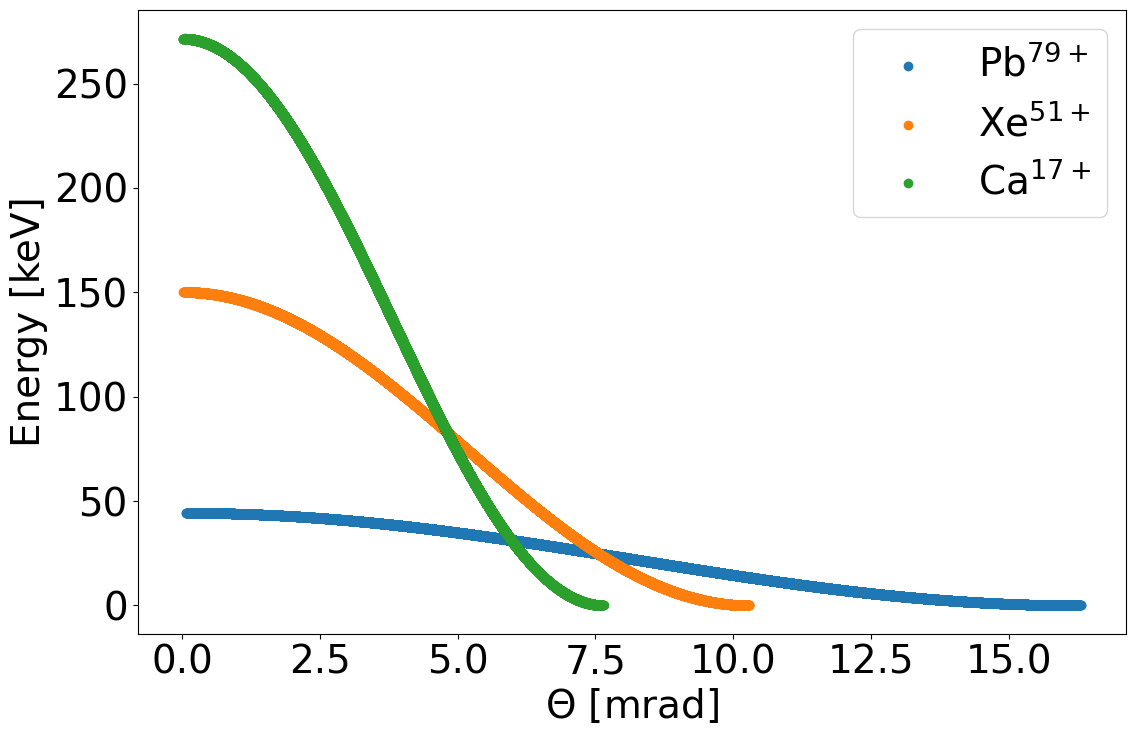

In [ ]:

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 28})

for ion in [lead,xenon,calcium]:# Ion properties:
        # Ion properties:
        q0=ion.q0
        mass0 = ion.mass0

        gamma = ion.gamma_rel
        beta = ion.beta_rel # ion beta
        p0c = gamma*mass0*beta #eV/c

        # # Source: https://www.sciencedirect.com/science/article/pii/S0146641020300399
        # # Equation 4.4
        # N_pb = int(1.9*1e8) #ion-bunch intensity for lead
        # N_a = int(N_pb*(ion.Z/82)**-1.9) #ion-bunch intensity for arbitrary ion with charge Z

        # Source: https://www.sciencedirect.com/science/article/pii/S0146641020300399
        # Ion beam dimensions:
        sigma_x = 1.047e-3 # m
        sigma_y = 0.83e-3  # m
        sigma_z = 0.063 # m
        sigma_dp = 2e-4 # relative ion momentum spread

        sigma_px=4.36*1e-3 #calculated from the Twiss parameters
        sigma_py=4.36*1e-3 #calculated from the Twiss parameters

        num_particles = int(2e5)

        particles0 = xp.Particles(
        mass0 = mass0, # eV/c^2
        q0    = q0,
        p0c   = p0c, # eV
        x     = np.random.normal(scale=sigma_x, size=num_particles),
        px    = np.random.normal(scale=sigma_px, size=num_particles),
        y     = np.random.normal(scale=sigma_y, size=num_particles),
        py    = np.random.normal(scale=sigma_py, size=num_particles),
        zeta  = np.random.normal(scale=sigma_z, size=num_particles),
        delta = np.random.normal(scale=sigma_dp, size=num_particles)
                )
        
        particles0._init_random_number_generator()

        ##################
        # Laser Cooler #
        ##################

        #Laser-ion beam collision angle
        theta_l = 2.6*np.pi/180 # rad
        #theta_l = ion.theta_l
        nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

        ion_excited_lifetime=ion.excited_lifetime
        # Ion excitation energy:
        hw0 = ion.hw0
        hc=constants.hbar*clight/constants.e # eV*m (ħc)
        lambda_0 = 2*np.pi*hc/hw0 # m -- ion excitation wavelength

        lambda_l = lambda_0*gamma*(1 + beta*np.cos(theta_l)) # m -- laser wavelength

        
        # Shift laser wavelength for fast longitudinal cooling:
        # lambda_l = lambda_l*(1+sigma_dp) # m

        laser_frequency = clight/lambda_l # Hz
        sigma_w = 2*np.pi*laser_frequency*sigma_dp
        #sigma_w = 2*np.pi*laser_frequency*sigma_dp/2 # for fast longitudinal cooling

        sigma_t = 1/sigma_w # sec -- Fourier-limited laser pulse
        #print('Laser pulse duration sigma_t = %.2f ps' % (sigma_t/1e-12))
        
        #print('Laser wavelength = %.2f nm' % (lambda_l/1e-9))

        laser_waist_radius = 1.3e-3 #m
        laser_energy = 5e-3
        #laser_energy = ion.pulse_energy
        GF_IP = xt.PulsedLaser(
                        laser_x=0,
                        laser_y=0,
                        laser_z=0,
                        
                        laser_direction_nx = 0,
                        laser_direction_ny = ny,
                        laser_direction_nz = nz,
                        laser_energy         = laser_energy, # J
                        laser_duration_sigma = sigma_t, # sec
                        laser_wavelength = lambda_l, # m
                        laser_waist_radius = laser_waist_radius, # m
                        laser_waist_shift = 0, # m
                        ion_excitation_energy = hw0, # eV
                        ion_excited_lifetime  = ion_excited_lifetime, # sec                   
                        )

        particles=particles0.copy()

        GF_IP.track(particles)

        excited=particles.state==2

        fraction_excitation = sum(excited)/len(excited)

        N_a=0.9*1e8
        N_a=ion.bunch_intensity

        circumference=6911.5038
        T_per_turn = circumference/(clight*beta)
        num_bunch_in_ring = 36
        
        print(f'Intensity of ion beam               : {N_a:.2e}')
        print(f'Fraction of excited particles       : {fraction_excitation*100:.3}%')
        print(f'Number of emitted photons per bunch : {fraction_excitation*N_a:.2e}')
        print('-----------------------------------------------------------------------')
        print(f'Number of emitted photons per bunch per second : {fraction_excitation*N_a/T_per_turn:.2e}')
        print(f'Number of emitted photons per second : {num_bunch_in_ring*fraction_excitation*N_a/T_per_turn:.2e}')
        print('-----------------------------------------------------------------------')
        
        omega_laser = 2 * np.pi * hc / lambda_l

        maximum_emitted_photon=hw0*2*gamma #Lorentz boost

        print(f'Laser_photon: {omega_laser:.2f} ev')
        print(f'hw0: {hw0:.2f} ev')
        print(f'Maximum_emitted_photon: {maximum_emitted_photon*1e-3:.2f} Kev')

        # Random polar angle in the ion's frame:
        costheta = np.random.uniform(-1,+1, size=num_particles)
        theta_emitt_ion = np.arccos(costheta)

        # Emitted photon energy in the lab frame:
        hw1_emitted = gamma*(1+particles0.delta) * ( 1 + beta*np.cos(theta_emitt_ion) )*hw0 # eV
        # Only excited atoms are emitting of course:
        hw1_excited_and_emitted = hw1_emitted *excited

        # Transverse emission doesn't have lorentz boost.
        # Only longitudinal has Lorenzt boost.
        # Therefore, the angle of outgoing angle of the photons is the Lorentz boost theta_emitt/(2*gamma)

        theta_photon_lab=theta_emitt_ion/(2*gamma) 

        plt.scatter(theta_photon_lab*1e3,hw1_emitted*1e-3,label=f'{ion.name}') #can also plot hw1_excited_and_emitted instead of hw1_emitted
plt.xlabel('$\Theta$ [mrad]')
plt.ylabel('Energy [keV]')
plt.legend()

image_name = 'photon_distribution.png'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
plt.show()

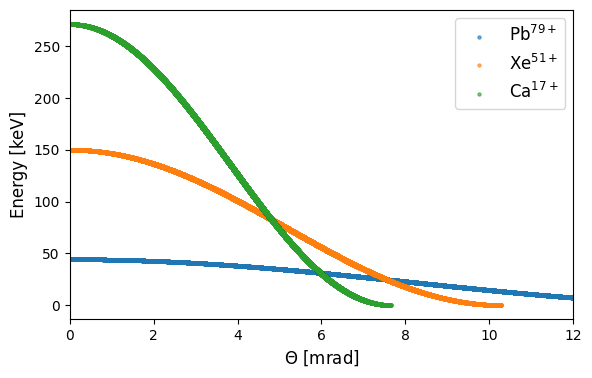

In [29]:
# Ensure plotting settings match the thesis format
plt.figure(figsize=(fig_width, fig_height))  # Use your predefined figure size
plt.rcParams.update({
    'font.size': label_fontsize, 
    'axes.labelsize': label_fontsize, 
    'legend.fontsize': legend_fontsize,
    'xtick.labelsize': tick_fontsize,
    'ytick.labelsize': tick_fontsize,
    'axes.titlesize': label_fontsize
})

for ion in [lead, xenon, calcium]:  # Loop over different ion species
    q0 = ion.q0
    mass0 = ion.mass0

    gamma = ion.gamma_rel
    beta = ion.beta_rel  
    p0c = gamma * mass0 * beta  

    sigma_x = 1.047e-3  # Beam size in x [m]
    sigma_y = 0.83e-3   # Beam size in y [m]
    sigma_z = 0.063     # Bunch length [m]
    sigma_dp = 2e-4     # Momentum spread

    sigma_px = 4.36e-3  
    sigma_py = 4.36e-3  

    num_particles = int(2e5)

    particles0 = xp.Particles(
        mass0=mass0, q0=q0, p0c=p0c,
        x=np.random.normal(scale=sigma_x, size=num_particles),
        px=np.random.normal(scale=sigma_px, size=num_particles),
        y=np.random.normal(scale=sigma_y, size=num_particles),
        py=np.random.normal(scale=sigma_py, size=num_particles),
        zeta=np.random.normal(scale=sigma_z, size=num_particles),
        delta=np.random.normal(scale=sigma_dp, size=num_particles)
    )

    particles0._init_random_number_generator()

    # Laser interaction
    theta_l = 2.6 * np.pi / 180  
    nx = 0; ny = -np.sin(theta_l); nz = -np.cos(theta_l)

    ion_excited_lifetime = ion.excited_lifetime
    hw0 = ion.hw0
    hc = constants.hbar * clight / constants.e  
    lambda_0 = 2 * np.pi * hc / hw0  

    lambda_l = lambda_0 * gamma * (1 + beta * np.cos(theta_l))  

    laser_frequency = clight / lambda_l  
    sigma_w = 2 * np.pi * laser_frequency * sigma_dp  
    sigma_t = 1 / sigma_w  

    laser_waist_radius = 1.3e-3  
    laser_energy = 5e-3  

    GF_IP = xt.PulsedLaser(
        laser_x=0, laser_y=0, laser_z=0,
        laser_direction_nx=0, laser_direction_ny=ny, laser_direction_nz=nz,
        laser_energy=laser_energy, laser_duration_sigma=sigma_t,
        laser_wavelength=lambda_l, laser_waist_radius=laser_waist_radius,
        laser_waist_shift=0, ion_excitation_energy=hw0, 
        ion_excited_lifetime=ion_excited_lifetime
    )

    particles = particles0.copy()
    GF_IP.track(particles)
    excited = particles.state == 2

    omega_laser = 2 * np.pi * hc / lambda_l
    max_emitted_photon = hw0 * 2 * gamma  

    # Emitted photon energy in the lab frame:
    costheta = np.random.uniform(-1, +1, size=num_particles)
    theta_emitt_ion = np.arccos(costheta)

    hw1_emitted = gamma * (1 + particles0.delta) * (1 + beta * np.cos(theta_emitt_ion)) * hw0  
    hw1_excited_and_emitted = hw1_emitted * excited

    theta_photon_lab = theta_emitt_ion / (2 * gamma)  

    plt.scatter(theta_photon_lab * 1e3, hw1_emitted * 1e-3, label=f'{ion.name}', alpha=0.6, s=5) 

# Plot formatting
plt.xlabel(r'$\Theta$ [mrad]', fontsize=label_fontsize)
plt.ylabel('Energy [keV]', fontsize=label_fontsize)
plt.legend(fontsize=label_fontsize)
plt.xlim(0,12)
# Save figure using predefined directory
image_name = 'photon_distribution.png'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')

plt.show()


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

x, px, y, py, zeta, delta = [getattr(particles, attr) for attr in ('x', 'px', 'y', 'py', 'zeta', 'delta')]
excited_indices = particles.state == 2  # Assuming this is how we get excited particles

z = zeta  # Assuming zeta represents the z-coordinate

# Assuming values for gamma_0, tau_0, mc
gamma_0 = gamma
tau_0 = ion.excited_lifetime

excited_indices = particles.state == 2  # Assuming this is how we get excited particles
Np_Excited = np.sum(excited_indices)

# random polar angle in the ion's frame:
cos_theta1p = np.random.uniform(-1,+1, size=Np_Excited)
theta1p = np.arccos(cos_theta1p)

# emission angle in the lab frame:
sin_theta1 = np.sin(theta1p)/(gamma_0 * (1+delta[excited_indices]) * ( 1 + beta*np.cos(theta1p) ))
theta1 = np.arcsin(sin_theta1)

# azimuthal angle of emission:
phi1 = np.random.uniform(0,2*np.pi, size=Np_Excited)

hw1_emitted = gamma_0 * (1 + delta[excited_indices]) * (1 + beta * np.cos(theta1p)) * hw0

# Emission process
dt_excited = gamma_0 * np.random.exponential(scale=tau_0, size=Np_Excited)
ds = dt_excited * constants.c

# Calculate photon emission details for excited ions
s_photon = z[excited_indices] + ds
x_photon = x[excited_indices] + ds * px[excited_indices]
y_photon = y[excited_indices] + ds * py[excited_indices]

p_photon  = hw1_emitted # eV/c
pz_photon = hw1_emitted * np.cos(theta1)
pt_photon = hw1_emitted * np.sin(theta1)
px_photon = pt_photon * np.cos(phi1)
py_photon = pt_photon * np.sin(phi1)


#delta[excited_indices] -= hw1_emitted / (gamma_0 * mass0)

xp_photon = px_photon/pz_photon # rad
yp_photon = py_photon/pz_photon # rad


xp_photon2 = px_photon/pz_photon +px[excited_indices] # rad
yp_photon2 = py_photon/pz_photon +py[excited_indices] # rad


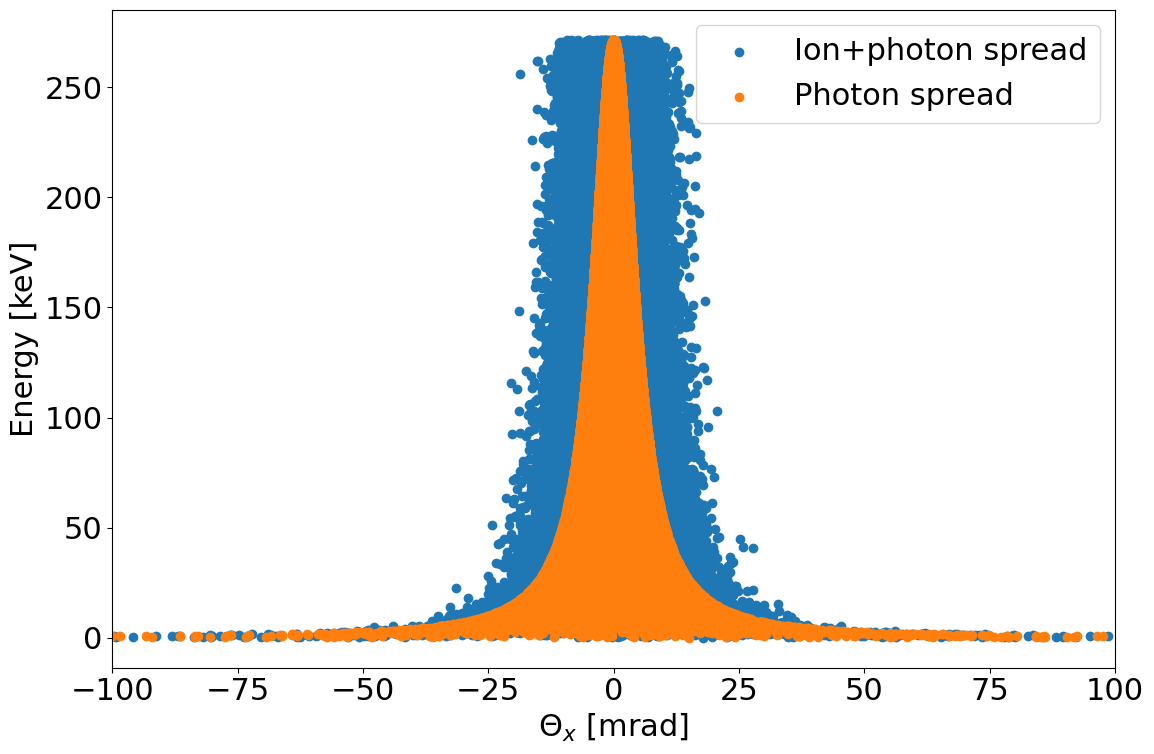

In [23]:
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 22})
plt.scatter(xp_photon2 * 1e3, p_photon * 1e-3, label=f'Ion+photon spread')  # Visualizing photon emission
plt.scatter(xp_photon * 1e3, p_photon * 1e-3, label=f'Photon spread')  # Visualizing photon emission


plt.xlabel('$\\Theta_x$ [mrad]')
plt.ylabel('Energy [keV]')
plt.xlim(-100,100)

plt.legend()
plt.tight_layout()
plt.savefig('figures/Photon_energy_distribution.png', dpi=300)
plt.show()


In [24]:
1/T_per_turn

43375.34969506986